# 01 — Graph Fundamentals and Message Passing

This notebook builds the graph-learning foundation needed for GCN, GraphSAGE, and GAT.

The central idea is:

> A node representation is updated using information from its neighbors.

The progression is:

**Graph structure** → **Adjacency matrix** → **Node features** → **Neighbor aggregation** → **Message passing**

## 1. Why graphs require a different representation

Tabular data usually treat rows as independent observations. Images have a regular 2D grid. Sequences have an ordered chain.

A graph is different because the **relationships between observations are part of the data**.

A graph is written as:

$$
G=(V,E)
$$

where:

- $V$ is the set of nodes,
- $E$ is the set of edges connecting nodes.

A graph-learning model therefore needs both **features** and **connectivity**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

np.set_printoptions(precision=3,suppress=True)

## 2. Load the toy graph

The toy graph has five nodes. Each node has two numerical features, and the edge file describes which nodes are connected.

The graph is intentionally small so every matrix can be inspected directly.

In [14]:
"""nodes = pd.read_csv("data/toy_graph_nodes.csv")
edges = pd.read_csv("data/toy_graph_edges.csv")

print(nodes)
print()
print(edges)"""

'nodes = pd.read_csv("data/toy_graph_nodes.csv")\nedges = pd.read_csv("data/toy_graph_edges.csv")\n\nprint(nodes)\nprint()\nprint(edges)'

In [4]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

nodes_file = [name for name in uploaded.keys() if "node" in name.lower()][0]
edges_file = [name for name in uploaded.keys() if "edge" in name.lower()][0]

nodes = pd.read_csv(nodes_file)
edges = pd.read_csv(edges_file)

print(nodes)
print()
print(edges)

Saving toy_graph_edges.csv to toy_graph_edges.csv
Saving toy_graph_nodes.csv to toy_graph_nodes.csv
  node  feature_1  feature_2
0    A        1.0        0.0
1    B        0.0        1.0
2    C        1.0        1.0
3    D        2.0        0.5
4    E        0.5        2.0

  source target
0      A      B
1      A      C
2      B      C
3      B      D
4      C      D
5      D      E


## 3. Visualize connectivity and node features

This plot is included because it directly represents the graph used in the later calculations.

Each label contains the node name and its feature vector.

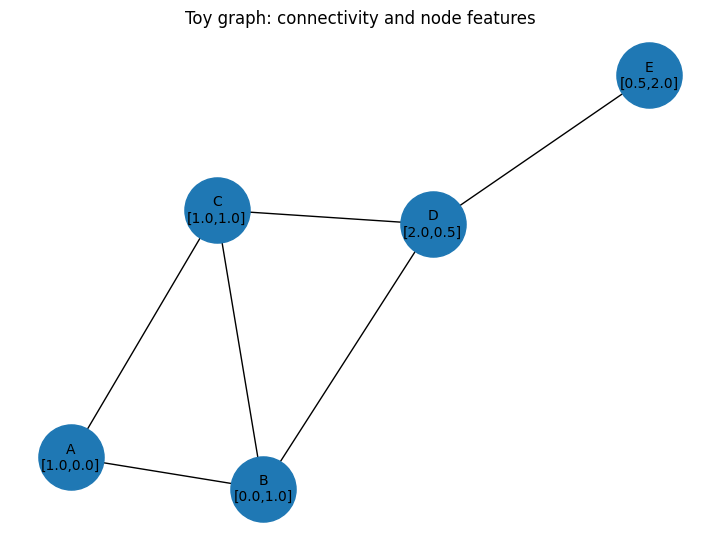

In [5]:
G = nx.Graph()

for _,row in nodes.iterrows():
    G.add_node(row["node"],features=[row["feature_1"],row["feature_2"]])

for _,row in edges.iterrows():
    G.add_edge(row["source"],row["target"])

labels = {row["node"]:f'{row["node"]}\n[{row["feature_1"]:.1f},{row["feature_2"]:.1f}]' for _,row in nodes.iterrows()}
pos = nx.spring_layout(G,seed=42)

plt.figure(figsize=(7,5))
nx.draw(G,pos,labels=labels,with_labels=True,node_size=2200,font_size=10)
plt.title("Toy graph: connectivity and node features")
plt.show()

## 4. Adjacency matrix

For an unweighted graph:

$$
A_{ij}
=
\begin{cases}
1, & \text{if nodes }i\text{ and }j\text{ are connected}\\
0, & \text{otherwise}
\end{cases}
$$

For an undirected graph, $A$ is symmetric.

In [6]:
node_order = nodes["node"].tolist()
A = nx.to_numpy_array(G,nodelist=node_order,dtype=float)

print("Node order:",node_order)
print()
print("Adjacency matrix A:")
print(A)
print()
print("A is symmetric:",np.allclose(A,A.T))

Node order: ['A', 'B', 'C', 'D', 'E']

Adjacency matrix A:
[[0. 1. 1. 0. 0.]
 [1. 0. 1. 1. 0.]
 [1. 1. 0. 1. 0.]
 [0. 1. 1. 0. 1.]
 [0. 0. 0. 1. 0.]]

A is symmetric: True


## 5. Degree matrix

The degree of node $i$ is:

$$
d_i=\sum_j A_{ij}
$$

The degree matrix is:

$$
D=\operatorname{diag}(d_1,d_2,\ldots,d_n)
$$

In [7]:
degrees = A.sum(axis=1)
D = np.diag(degrees)

print("Degrees:")
print(degrees)
print()
print("Degree matrix D:")
print(D)

Degrees:
[2. 3. 3. 3. 1.]

Degree matrix D:
[[2. 0. 0. 0. 0.]
 [0. 3. 0. 0. 0.]
 [0. 0. 3. 0. 0.]
 [0. 0. 0. 3. 0.]
 [0. 0. 0. 0. 1.]]


## 6. Node-feature matrix

If there are $N$ nodes and $F$ features per node:

$$
X\in\mathbb{R}^{N\times F}
$$

Each row of $X$ belongs to one node.

In [8]:
X = nodes[["feature_1","feature_2"]].to_numpy(dtype=float)

print("Feature matrix X:")
print(X)
print()
print("X shape:",X.shape)

Feature matrix X:
[[1.  0. ]
 [0.  1. ]
 [1.  1. ]
 [2.  0.5]
 [0.5 2. ]]

X shape: (5, 2)


## 7. Why $AX$ aggregates neighbor features

Consider:

$$
AX
$$

Row $i$ of $AX$ is the sum of the feature vectors of the neighbors of node $i$.

This is the first important bridge from graph structure to neural computation.

In [9]:
AX = A @ X

print("A @ X:")
print(AX)

A @ X:
[[1.  2. ]
 [4.  1.5]
 [3.  1.5]
 [1.5 4. ]
 [2.  0.5]]


### 7.1 Verify node A manually

Node A is connected to B and C.

$$
x_B=[0,1]
$$

$$
x_C=[1,1]
$$

Therefore:

$$
x_B+x_C=[1,2]
$$

The first row of $AX$ should also be $[1,2]$.

In [10]:
neighbors_A = list(G.neighbors("A"))
manual_A = nodes.set_index("node").loc[neighbors_A,["feature_1","feature_2"]].to_numpy().sum(axis=0)

print("Neighbors of A:",neighbors_A)
print("Manual neighbor sum:",manual_A)
print("First row of A @ X:",AX[0])

Neighbors of A: ['B', 'C']
Manual neighbor sum: [1. 2.]
First row of A @ X: [1. 2.]


## 8. A simple message-passing rule

Let $h_i^{(l)}$ be the representation of node $i$ at layer $l$.

A simple aggregation is:

$$
m_i^{(l)}
=
\sum_{j\in\mathcal{N}(i)}
h_j^{(l)}
$$

Then combine the node's own representation with the aggregated neighbor message:

$$
h_i^{(l+1)}
=
\sigma
\left(
W_{\text{self}}h_i^{(l)}
+
W_{\text{neighbor}}m_i^{(l)}
\right)
$$

## 9. Complete numerical message-passing example

For node A:

$$
h_A=
\begin{bmatrix}
1\\
0
\end{bmatrix},
\qquad
h_B=
\begin{bmatrix}
0\\
1
\end{bmatrix},
\qquad
h_C=
\begin{bmatrix}
1\\
1
\end{bmatrix}
$$

The neighbor message is:

$$
m_A=h_B+h_C=
\begin{bmatrix}
1\\
2
\end{bmatrix}
$$

Use:

$$
W_{\text{self}}
=
\begin{bmatrix}
0.5 & 0.2\\
0.1 & 0.7
\end{bmatrix}
$$

and:

$$
W_{\text{neighbor}}
=
\begin{bmatrix}
0.6 & -0.2\\
0.3 & 0.4
\end{bmatrix}
$$

Then:

$$
z_A=W_{\text{self}}h_A+W_{\text{neighbor}}m_A
$$

and:

$$
h_A'=\operatorname{ReLU}(z_A)
$$

In [11]:
h_A = np.array([1.0,0.0])
h_B = np.array([0.0,1.0])
h_C = np.array([1.0,1.0])

W_self = np.array([[0.5,0.2],[0.1,0.7]])
W_neighbor = np.array([[0.6,-0.2],[0.3,0.4]])

m_A = h_B+h_C
self_part = W_self @ h_A
neighbor_part = W_neighbor @ m_A
z_A = self_part+neighbor_part
h_A_new = np.maximum(z_A,0)

print("Neighbor message m_A:",m_A)
print("Self contribution:",self_part)
print("Neighbor contribution:",neighbor_part)
print("Pre-activation z_A:",z_A)
print("Updated representation h_A':",h_A_new)

Neighbor message m_A: [1. 2.]
Self contribution: [0.5 0.1]
Neighbor contribution: [0.2 1.1]
Pre-activation z_A: [0.7 1.2]
Updated representation h_A': [0.7 1.2]


## 10. Aggregation must be permutation invariant

Graphs do not define a meaningful order for neighbors.

If node A has neighbors $\{B,C\}$, then listing them as $\{C,B\}$ should not change the result.

Useful graph aggregation functions therefore include:

$$
\operatorname{SUM},\qquad
\operatorname{MEAN},\qquad
\operatorname{MAX}
$$

In [12]:
neighbor_features_1 = np.vstack([h_B,h_C])
neighbor_features_2 = np.vstack([h_C,h_B])

sum_1 = neighbor_features_1.sum(axis=0)
sum_2 = neighbor_features_2.sum(axis=0)

print("B then C:",sum_1)
print("C then B:",sum_2)
print("Same result:",np.allclose(sum_1,sum_2))

B then C: [1. 2.]
C then B: [1. 2.]
Same result: True


## 11. General message-passing neural network view

Many GNNs can be summarized using two stages.

### Aggregation

$$
m_i^{(l)}
=
\operatorname{AGGREGATE}
\left(
\left\{
h_j^{(l)}:
j\in\mathcal{N}(i)
\right\}
\right)
$$

### Update

$$
h_i^{(l+1)}
=
\operatorname{UPDATE}
\left(
h_i^{(l)},m_i^{(l)}
\right)
$$

GCN, GraphSAGE, and GAT mainly differ in **how they aggregate and transform neighborhood information**.

## 12. One-hop and two-hop information

After one message-passing layer, a node receives information from its immediate neighbors.

After two layers, it can indirectly receive information from neighbors of neighbors.

The plot below marks the graph according to distance from node A.

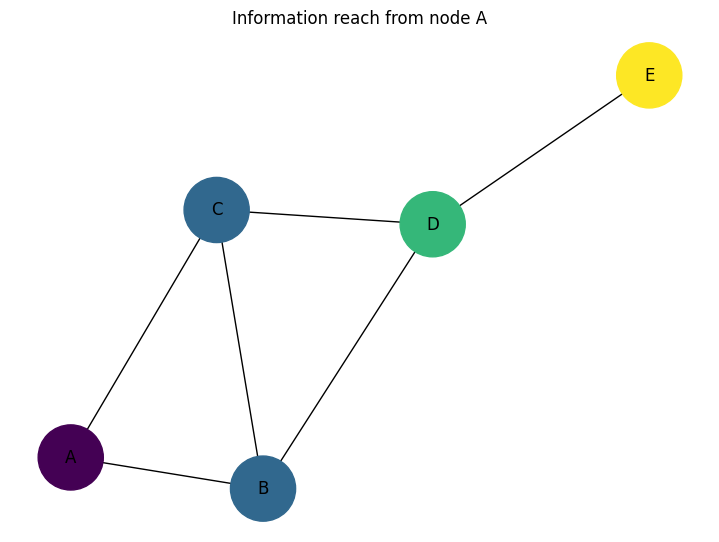

1-hop neighbors: ['B', 'C']
2-hop-only neighbors: ['D']


In [13]:
center = "A"
one_hop = set(G.neighbors(center))
two_hop = set()

for node in one_hop:
    two_hop.update(G.neighbors(node))

two_hop.discard(center)
two_hop = two_hop-one_hop

node_groups = []

for node in G.nodes():
    if node == center:
        node_groups.append(0)
    elif node in one_hop:
        node_groups.append(1)
    elif node in two_hop:
        node_groups.append(2)
    else:
        node_groups.append(3)

plt.figure(figsize=(7,5))
nx.draw(G,pos,labels={n:n for n in G.nodes()},with_labels=True,node_size=2200,node_color=node_groups,cmap="viridis")
plt.title("Information reach from node A")
plt.show()

print("1-hop neighbors:",sorted(one_hop))
print("2-hop-only neighbors:",sorted(two_hop))

## 13. Graph-learning task levels

### Node classification

Predict one label or value per node.

Examples: paper topic, user type, fraud status.

### Edge or link prediction

Predict whether two nodes should be connected or predict an edge property.

Examples: recommendation links, interactions, relationships.

### Graph classification

Predict one label or value for an entire graph.

Examples: molecular properties or whole-network categories.

## 14. Key takeaways

1. A graph contains both **features** and **relationships**.
2. The adjacency matrix encodes connectivity.
3. Multiplying by the adjacency matrix aggregates neighbor information.
4. Message passing alternates between **aggregation** and **update**.
5. Multiple GNN layers expand how far information can travel.
6. The next notebook develops Graph Convolutional Networks using normalized adjacency.